In [1]:
import pandas as pd
import numpy as np 
from pathlib import Path 
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
np.random.seed(42)


base = Path(r"C:\Users\ENZO\Documents\DIPLOMADO ESTADÍSTICA Y ANALÍTICA DE DATOS\MÓDULO 6 - TRABAJO FINAL\Wind Farm A")
event_info = pd.read_csv(base / "event_info.csv", sep=";")

# ==============================
# 1. CARGAS EVENTOS
# ==============================

# Carga un evento, retorna sensor_cols, normal_status, train_mask, test_mask
def load_event(event_id):
    df = pd.read_csv(base / f"{event_id}.csv", sep=";", parse_dates=["time_stamp"])
    df = df.set_index("time_stamp").sort_index()
    return df

# ==============================
# 2. PRE PROCESAMIENTO DE DATOS
# ==============================

# Carga todos los eventos de un asset y retornar X_train y X_test
def preprocess_data(asset_id, asset_events):
    
    # 1.1. Identificar los timestamps sagrados
    sacred_timestamps = set()
    for evid in asset_events["event_id"]:
        df = load_event(evid)
        sacred_timestamps.update(df.index[df["train_test"] == "prediction"])
    print(f" Timestamps sagrados (suma de predictions): {len(sacred_timestamps)}")

    # 2. Construir dataset unificado del asset (aerogenerador)
    pieces = []
    for evid in asset_events["event_id"]:
        df = load_event(evid)
        pieces.append(df)
    
    unified = pd.concat(pieces)

    # 2.1. Deduplicar por timestamp (queda 1 copia de cada momento real)
    unified = unified[~unified.index.duplicated(keep="first")]

    # 2.2. Ordenar cronológicamente
    unified = unified.sort_index()

    # 2.3. Filtrar dataframe de entrenamiento y predicción
    df_train = unified[(unified["status_type_id"]==0) & (unified["train_test"]=="train")]

    # 2.4. Eliminar timestamps sagrados (que están presentes en dataframe de entrenamiento)
    sacred_mask = df_train.index.isin(sacred_timestamps)
    df_train_clean = df_train[~sacred_mask]
    print(f"  Filas excluidas por estar en algún prediction: {sacred_mask.sum()}")

    # 3. Preprocesamiento
    meta_cols = ["asset_id", "id", "train_test", "status_type_id"]
    sensor_cols = [c for c in df_train_clean.columns if c not in meta_cols]
    X_train = df_train_clean[sensor_cols].copy()

    # 3.1. Filtros de variables que contienen valores nulos
    nan_frac = X_train.isna().mean()
    cols_keep = nan_frac[nan_frac <= 0.05].index.tolist()
    unique_counts = X_train[cols_keep].nunique()
    cols_keep = unique_counts[unique_counts >= 2].index.tolist()
    X_train = X_train[cols_keep]

    # 3.2. Imputar y escalar X_test y X_train 
    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(X_train)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_imp)

    return {
        "X_train_scaled": X_train_scaled,
        "imputer": imputer,
        "scaler": scaler,
        "cols": cols_keep,
    }


In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model

tf.random.set_seed(42)
# ====================================================
# 3. CONSTRUIR AUTOENCODER (APRENDER REPRESENTACIONES)
# ====================================================

def build_autoencoder(n_features, code_size=20, hidden_layers=(200, 100, 50)):
    inputs = layers.Input(shape=(n_features,))
    x = inputs
    for units in hidden_layers:
        x = layers.Dense(units)(x)
        x = layers.PReLU()(x)
    x = layers.Dense(code_size)(x)
    encoded = layers.PReLU(name="encoded")(x)
    x = encoded
    for units in reversed(hidden_layers):
        x = layers.Dense(units)(x)
        x = layers.PReLU()(x)
    outputs = layers.Dense(n_features)(x)
    return Model(inputs, outputs, name="autoencoder")

# ====================================================
# 4. TRAIN/VAL SPLIT Y ENTRENAMIENTO
# ====================================================

def train_event (X_train_scaled, epochs=50, batch_size=128, verbose=0):
    
    # 1. Dividir dataframe de entrenamiento entre entrenamiento y validación para el entrenamiento del autoencoder
    X_tr, X_val = train_test_split(X_train_scaled, test_size=0.2, shuffle=True, random_state=42)
    n_features = X_tr.shape[1]

    autoencoder = build_autoencoder(n_features=n_features, code_size=20)
    autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
    history = autoencoder.fit(
        X_tr, X_tr,
        validation_data=(X_val, X_val),
        epochs=epochs, batch_size=batch_size, verbose=verbose
    )

    # 2. Calcular el umbral
    X_recon = autoencoder.predict(X_train_scaled, verbose=0)
    rmse_train = np.sqrt(np.mean((X_train_scaled - X_recon) ** 2, axis=1))
    threshold = np.quantile(rmse_train, 0.99)
    print(f"  Umbral: {threshold:.4f}")
    
    return {
        "model": autoencoder,
        "threshold": threshold,
    }   

# ====================================================
# 5. PREDICCIÓN DEL EVENTO
# ====================================================

# Cargar evento de prueba y retornar anomaly score y predicted anomalies
def predict_event(asset_artifacts, event_id):
    # 1. Cargar evento de prueba
    df = load_event(event_id)
    df_test = df[df["train_test"]=="prediction"]
    
    # 2. Definir X_test según las mismas condiciones que X_train
    X_test = df_test[asset_artifacts["cols"]].copy()

    # 3. Imputar y escalar X_test
    X_test_imp = asset_artifacts["imputer"].transform(X_test)
    X_test_scaled = asset_artifacts["scaler"].transform(X_test_imp)

    # 4. Predicción del evento
    X_recon = asset_artifacts["model"].predict(X_test_scaled, verbose=0)
    rmse_test = np.sqrt(np.mean((X_test_scaled - X_recon)**2, axis=1))

    # 5. Calcular anomaly score
    anomaly_score = pd.Series(rmse_test / asset_artifacts["threshold"], index=df_test.index)
    predicted_anomalies = anomaly_score > 1.0
    return anomaly_score, predicted_anomalies

# =============================================================================
# 6. MÉTRICAS DE EVALUACIÓN CARE (COVERAGE, ACCURACY, RELIABILTY AND EARLINESS)
# =============================================================================

# Cargar predicted anomalies y event info para retornar lista de métricas CARE
def care_components (predicted_anomalies, event_row, min_frac=0.1, beta=0.5):
    fault_start = pd.to_datetime(event_row["event_start"])
    fault_end = pd.to_datetime(event_row["event_end"])
    in_window = (predicted_anomalies.index >= fault_start) & (predicted_anomalies.index <= fault_end)
    
    out = {
        "event_id": event_row.name, "asset": event_row["asset"],
        "label": event_row["event_label"],
        "description": event_row["event_description"] if pd.notna(event_row["event_description"]) else "normal",
        "n_test": len(predicted_anomalies),
        "n_anomalies_detected": int(predicted_anomalies.sum()),
    }
    
    if event_row["event_label"] == "anomaly":
        tp_in = int((predicted_anomalies & in_window).sum())
        fp_in = int((predicted_anomalies & ~in_window).sum())
        fn_in = int((~predicted_anomalies & in_window).sum())
        total_in = int(in_window.sum())
        
        if total_in == 0 or (tp_in / total_in) < min_frac:
            coverage = 0.0
        else:
            p = tp_in / (tp_in + fp_in) if (tp_in + fp_in) > 0 else 0
            r = tp_in / (tp_in + fn_in) if (tp_in + fn_in) > 0 else 0
            coverage = (1 + beta**2) * p * r / (beta**2 * p + r) if (p + r) > 0 else 0.0
        
        anom_in_window = predicted_anomalies[in_window & predicted_anomalies]
        if len(anom_in_window) > 0:
            time_to_detect = anom_in_window.index[0] - fault_start
            duration = fault_end - fault_start
            earliness = 1 - (time_to_detect.total_seconds() / duration.total_seconds())
            event_detected = True
        else:
            earliness = 0.0
            event_detected = False
        
        out.update({"coverage": round(coverage, 3), "earliness": round(earliness, 3),
                    "accuracy": None, "event_detected": event_detected})
    else:
        accuracy = float((~predicted_anomalies).mean())
        false_alarm = predicted_anomalies.sum() > (min_frac * len(predicted_anomalies))
        out.update({"coverage": None, "earliness": None,
                    "accuracy": round(accuracy, 3), "event_detected": false_alarm})
    return out    

# ================================================================================
# 7. sensor ANALYSIS PARA IDENTIFICAR LAS POSIBLES CAUSAS RAICES DE LAS ANOMALÍAS
# ================================================================================
# Análisis de causa raíz: Identifica los sensores con mayor contribución al error
# de reconstrucción durante la ventana de falla
# Retorna:
#       - recon_error_df: error por sensor por timestamp
#       - top_sensors_event: ranking de sensores en todo el evento
#       - top_sensors_window: ranking de sensores DENTRO de la ventana de falla
#       - top_sensors_first_alarm: ranking en el momento de la primera alarma
 
def sensor_analysis(asset_artifacts, event_id, top_n=10):

    # Verificar tipo de evento
    ev_row = event_info.set_index("event_id").loc[event_id]
    if ev_row["event_label"] != "anomaly":
        print(f"   Evento {event_id} es '{ev_row['event_label']}' — sensor no aplica.")
        print(f"   sensor solo identifica sensores culpables en eventos con falla real.")
        return None
    
    # 1. Cargar datos del evento
    df = load_event(event_id)
    df_test = df[df["train_test"]=="prediction"]
    
    # 2. Definir X_test según las mismas condiciones que X_train
    X_test = df_test[asset_artifacts["cols"]].copy()

    # 3. Imputar y escalar X_test
    X_test_imp = asset_artifacts["imputer"].transform(X_test)
    X_test_scaled = asset_artifacts["scaler"].transform(X_test_imp)

    # 4. Predicción del evento )(reconstrucción)
    X_recon = asset_artifacts["model"].predict(X_test_scaled, verbose=0)   

    # 5. Error por sensor por timestamp (en escala estandarizada, por eso es comparable)
    recon_error_df = pd.DataFrame(
        np.abs(X_test_scaled - X_recon),
        index = df_test.index,
        columns = asset_artifacts["cols"]
    )

    # 6. Ranking 1: promedio en todo el evento
    top_event = recon_error_df.mean().sort_values(ascending=False).head(top_n)

    # 6.1. Raking actual: en un momento dado
    top_current = recon_error_df.iloc[-1].sort_values(ascending=False).head(top_n)

    # 7. Ranking 2: promedio dentro de la ventana de falla
    ev_row = event_info.set_index("event_id").loc[event_id]
    fault_start = pd.to_datetime(ev_row["event_start"])
    fault_end = pd.to_datetime(ev_row["event_end"])
    in_window = (recon_error_df.index >= fault_start) & (recon_error_df.index <= fault_end)

    if in_window.sum() > 0:
        top_window = recon_error_df.loc[in_window].mean().sort_values(ascending=False).head(top_n)
    else:
        top_window = None

    # 8. Ranking 3: en el momento de la primera alarma
    rmse_test = np.sqrt(np.mean((X_test_scaled - X_recon) ** 2, axis=1))
    anomaly_score = pd.Series(rmse_test / asset_artifacts["threshold"], index=df_test.index)
    predicted_anomalies = anomaly_score > 1.0
    
    first_alarm_in_window = predicted_anomalies[in_window & predicted_anomalies]
    if len(first_alarm_in_window) > 0:
        first_alarm_ts = first_alarm_in_window.index[0]
        top_first_alarm = recon_error_df.loc[first_alarm_ts].sort_values(ascending=False).head(top_n)
    else:
        top_first_alarm = None   

    return {
        "recon_error_df": recon_error_df,
        "top_event": top_event,
        "top_current" : top_current,
        "top_window": top_window,
        "top_first_alarm": top_first_alarm,
        "ev_row": ev_row
    }



c:\Users\ENZO\venv-fault\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


In [ ]:
# ================================================================================
# 8. SISTEMA DE ALERTA ESCALONADA SEGÚN LOS RESULTADOS DEL MODELO Y sensor
# ================================================================================
#   Determina el nivel de protocolo de proteccion con:
#    - Deteccion de falla subita por gradiente (Rate of Change) sobre ventana corta
#    - Filtro de confirmacion para Nivel 4 (evita efecto latigo)
#    - Clasificacion del modo de falla (subita / gradual / indeterminada)
#
#   NOTA: el protocolo CLASIFICA gravedad del estado actual; NO pronostica RUL.
#   El analisis de las 12 imagenes de degradacion mostro que las fallas de este
#   parque son mayoritariamente subitas o sin firma seguible, por lo que el RUL
#   por extrapolacion no es viable. El protocolo es un sistema de alerta, no de
#   pronostico.
#
# Argumentos:
#   anomaly_score:          Series completo del score (indice temporal)
#   predicted_anomalies:    Series booleana de alarmas
#   sensor_top_sensors:     Series/lista con sensores culpables (de sensor)
#   confirmation_steps_L4:  Timesteps consecutivos requeridos para Nivel 4
#                           (default 2 = 20 minutos)
#   sudden_delta_threshold: Salto minimo de score para declarar falla subita
#                           (default 1.5), medido sobre ventana corta
#   sudden_window:          N timesteps de la ventana de gradiente (default 6 = 1h)

def determine_protocol_level(anomaly_score, predicted_anomalies,
                              sensor_top_sensors,
                              confirmation_steps_L4=2,
                              sudden_delta_threshold=1.5,
                              sudden_window=6):

    PREFIJOS_TERMICOS = [          # rodamientos/bobinados generador, gearbox, trafo
        "sensor_11", "sensor_12",                           # multiplicadora
        "sensor_13", "sensor_14", "sensor_15", "sensor_16",
        "sensor_17", "sensor_19", "sensor_20",              # generador
        "sensor_38", "sensor_39", "sensor_40",              # transformador
    ]
    PREFIJOS_RED = [               # potencia y red electrica
        "reactive_power_27", "reactive_power_28",
        "power_29", "power_30", "sensor_31",
    ]
    PREFIJOS_ELECTRICOS = [       
        "sensor_22", "sensor_23", "sensor_24", "sensor_25",
        "sensor_26", "sensor_32", "sensor_33", "sensor_34",
    ]
    PREFIJOS_HIDRAULICOS = [    
        "sensor_41",
    ]

    def _match(sensor_list, prefijos):
       
        for s in sensor_list:
            for p in prefijos:
                
                if s == p or s.startswith(p + "_"):
                    return True
        return False

    # ── Valores actuales ───────────────────────────────────────────────────
    current_score = float(anomaly_score.iloc[-1])

    # ── 1. GRADIENTE: Rate of Change sobre ventana corta ──────────────────
    n = len(anomaly_score)
    if n > sudden_window:
        ventana = anomaly_score.iloc[-(sudden_window + 1):]
        delta_score = float(ventana.iloc[-1] - ventana.iloc[0])
        difs = ventana.diff().dropna()
        pasos_subida = int((difs > 0).sum())
        ascenso_consistente = pasos_subida >= (sudden_window * 0.6)
    else:
        prev = float(anomaly_score.iloc[-2]) if n >= 2 else current_score
        delta_score = current_score - prev
        ascenso_consistente = delta_score > 0

    is_sudden = (delta_score > sudden_delta_threshold) and ascenso_consistente

    # ── 2. PERSISTENCIA en ventana de 3 horas ─────────────────────────────
    last_N = 18   # 18 x 10 min = 3 horas
    recent_alarms = int(predicted_anomalies.iloc[-last_N:].sum())
    persistence_ratio = recent_alarms / last_N

    # ── 3. SENSORES sensor ─────────────────────────────────────────────────
    if hasattr(sensor_top_sensors, "index"):
        top_sensors = list(sensor_top_sensors.index)
    else:
        top_sensors = list(sensor_top_sensors)

    es_termico    = _match(top_sensors, PREFIJOS_TERMICOS)
    es_red        = _match(top_sensors, PREFIJOS_RED)
    es_electrico  = _match(top_sensors, PREFIJOS_ELECTRICOS)
    es_hidraulico = _match(top_sensors, PREFIJOS_HIDRAULICOS)

    # ── 4. FILTRO DE CONFIRMACION para Nivel 4 ────────────────────────────
    # Nivel 4 solo se activa si la anomalia persiste N timesteps consecutivos.
    # Evita disparos por picos transitorios 
    ultimos_N_L4    = int(predicted_anomalies.iloc[-confirmation_steps_L4:].sum())
    confirmacion_L4 = (ultimos_N_L4 == confirmation_steps_L4)

    # ── 5. DETERMINACION DEL NIVEL ─────────────────────────────────────────
    # Prioridad: Nivel 4 > Nivel 3 > Nivel 2 > Nivel 1 > Nivel 0
    sensores_red_activos = [s for s in top_sensors
                            if _match([s], PREFIJOS_RED)]

    if es_red and current_score > 2.0 and confirmacion_L4:
        nivel = 4
        razon = (f"Sensores de red activos ({sensores_red_activos}) "
                 f"con score={current_score:.2f} sostenido {confirmation_steps_L4} "
                 f"timesteps ({confirmation_steps_L4*10} min) -> desconexion confirmada")

    elif es_red and current_score > 2.0 and not confirmacion_L4:
        nivel = 3
        razon = (f"Posible transitorio electrico (score={current_score:.2f}, "
                 f"delta={delta_score:+.2f}). Esperando confirmacion "
                 f"{confirmation_steps_L4} timesteps para Nivel 4. "
                 f"Parada controlada preventiva.")

    elif is_sudden and current_score > 1.5:
        # Falla subita detectada por gradiente. Umbral de score bajado a 1.5
        nivel = 3
        razon = (f"FALLA SUBITA DETECTADA: delta_score={delta_score:+.2f} en "
                 f"ventana de {sudden_window} pasos (umbral={sudden_delta_threshold}). "
                 f"Score={current_score:.2f}. Inspeccion fisica inmediata + sensor.")

    elif current_score > 4.0 or (es_termico and current_score > 3.0):
        nivel = 3
        razon = (f"Score critico ({current_score:.2f})"
                 + (" con sensor termico activo" if es_termico else "")
                 + " -> parada controlada")

    elif current_score > 2.5 or (persistence_ratio > 0.5 and current_score > 1.5):
        nivel = 2
        razon = (f"Score={current_score:.2f}, persistencia 3h="
                 f"{persistence_ratio*100:.0f}% -> derating al 70%")

    elif current_score > 1.5 or persistence_ratio > 0.3:
        nivel = 1
        razon = (f"Score={current_score:.2f}, persistencia 3h="
                 f"{persistence_ratio*100:.0f}% -> monitoreo aumentado")

    else:
        nivel = 0
        razon = f"Operacion normal (score={current_score:.2f})"

    # ── 6. MODO DE FALLA ───────────────────────────────────────────────────
    if is_sudden:
        modo_falla    = "SUBITA"
        recomendacion = ("Falla de evolucion rapida -> inspeccion fisica "
                         "inmediata + diagnostico sensor. Pronostico RUL no aplicable.")
    elif es_termico and nivel >= 2:
        modo_falla    = "TERMICA SOSTENIDA"
        recomendacion = ("Componente termico con anomalia sostenida -> seguimiento "
                         "de tendencia del sensor afectado e inspeccion programada. "
                         "No constituye un pronostico RUL fiable.")
    elif nivel >= 2:
        modo_falla    = "INDETERMINADA"
        recomendacion = ("Modo de falla sin clasificar -> monitorear 2h y ejecutar "
                          "sensor en paralelo para localizar el componente.")
    else:
        modo_falla    = "NORMAL"
        recomendacion = "Sin accion requerida."

    # ── 7. ACCIONES POR NIVEL ──────────────────────────────────────────────
    ACCIONES = {
        0: "Operacion normal. Log interno.",
        1: "Monitoreo cada 1 min. Notificacion tecnico. Inspeccion en 48h.",
        2: ("DERATING 70% potencia + 80% RPM. Orden de trabajo inmediata. "
            "Inspeccion en 24h."),
        3: ("PARADA CONTROLADA (rampa descendente). Tecnico en sitio hoy. "
            "Bloqueo hasta revision."),
        4: ("DESCONEXION DE RED. Interruptor principal abierto. "
            "Protecciones electricas activadas. Bloqueo total."),
    }

    return {
        # Estado actual
        "nivel":               nivel,
        "score_actual":        round(current_score, 3),
        "delta_score":         round(delta_score, 3),
        "is_sudden":           is_sudden,
        "persistencia_3h_pct": round(persistence_ratio * 100, 1),
        "confirmacion_L4":     confirmacion_L4,
        # Sensores
        "sensor_termico":      es_termico,
        "sensor_red":          es_red,
        "sensor_electrico":    es_electrico,
        "sensor_hidraulico":   es_hidraulico,
        "top_sensors":         top_sensors[:5],
        # Diagnostico
        "modo_falla":          modo_falla,
        "razon":               razon,
        "accion":              ACCIONES[nivel],
        "recomendacion":       recomendacion,
    }


# ================================================================================
# 9. IMPRIME UN REPORTE LEGIBLE DEL ESTADO DEL PROTOCOLO
# ================================================================================
def print_protocol_report(result, timestamp=None):

    COLORES_NIVEL = {
        0: "NORMAL",
        1: "ALERTA",
        2: "DEGRADADO",
        3: "CRITICO",
        4: "EMERGENCIA",
    }

    ts = timestamp.strftime("%Y-%m-%d %H:%M") if timestamp else "N/A"

    print(f"\n{'='*65}")
    print(f"  REPORTE DE PROTOCOLO - {ts}")
    print(f"{'='*65}")
    print(f"  NIVEL:           {result['nivel']} - {COLORES_NIVEL[result['nivel']]}")
    print(f"  Score actual:    {result['score_actual']}")
    print(f"  Delta score:     {result['delta_score']:+.3f}"
          + ("  [FALLA SUBITA]" if result['is_sudden'] else ""))
    print(f"  Persistencia:    {result['persistencia_3h_pct']}% en ultimas 3h")
    print(f"  Confirmacion L4: {'si' if result['confirmacion_L4'] else 'no (esperando)'}")
    print(f"\n  Sensores activos:")
    print(f"    Top sensor:    {result['top_sensors']}")
    print(f"    Termico:       {'SI' if result['sensor_termico'] else 'no'}")
    print(f"    Red:           {'SI' if result['sensor_red'] else 'no'}")
    print(f"    Electrico:     {'SI' if result['sensor_electrico'] else 'no'}")
    print(f"    Hidraulico:    {'SI' if result['sensor_hidraulico'] else 'no'}")
    print(f"\n  Modo de falla:   {result['modo_falla']}")
    print(f"  Razon:           {result['razon']}")
    print(f"\n  ACCION:          {result['accion']}")
    print(f"  Recomendacion:   {result['recomendacion']}")
    print(f"{'='*65}")


In [ ]:
# =============================================================================
# 10. EJECUCIÓN DE TODOS LOS EVENTOS DE PRUEBA POR ASSET ID (AEROGENERADOR)
# =============================================================================

# A partir de event info cargas los eventos de prueba para evaluar los resultados
results_per_event = []
asset_artifacts_dict = {}
for asset_id, asset_events in event_info.groupby("asset"):
    data_results = preprocess_data(asset_id, asset_events)
    X_train_scaled = data_results["X_train_scaled"]
    train_results = train_event(X_train_scaled)
    artifacts = {
        **data_results,
        **train_results
    }
    asset_artifacts_dict[asset_id] = artifacts

    for evid in asset_events["event_id"]:
        anomaly_score, predicted_anomalies = predict_event(artifacts, evid)
        ev_row = event_info.set_index("event_id").loc[evid]
        comp = care_components(predicted_anomalies, ev_row)
        results_per_event.append(comp)

        cov = comp.get("coverage")
        earl = comp.get("earliness")
        acc =  comp.get("accuracy")
        print(f"    Evento {evid:3d} [{comp['label']:7s}] {comp['description'][:30]:30s}: "
              f"det={str(comp['event_detected']):5s} "
              f"cov={cov if cov is not None else '-':>5} "
              f"earl={earl if earl is not None else '-':>5} "
              f"acc={acc if acc is not None else '-':>5}")   

# =============================
# 11. RESUMEN CARE SCORE GLOBAL
# =============================
df = pd.DataFrame(results_per_event)
print(f"\n\n{'='*70}")
print("RESULTADOS")
print(f"{'='*70}")
print(df.to_string(index=False))

anom = df[df["label"] == "anomaly"]
norm = df[df["label"] == "normal"]

avg_coverage = anom["coverage"].mean()
detected = anom[anom["earliness"] > 0]
avg_earliness = detected["earliness"].mean() if len(detected) > 0 else 0.0
avg_accuracy = norm["accuracy"].mean()

tp_e = int(((df["label"] == "anomaly") & (df["event_detected"])).sum())
fp_e = int(((df["label"] == "normal") & (df["event_detected"])).sum())
fn_e = int(((df["label"] == "anomaly") & (~df["event_detected"])).sum())
tn_e = int(((df["label"] == "normal") & (~df["event_detected"])).sum())

beta = 0.5
p_e = tp_e / (tp_e + fp_e) if (tp_e + fp_e) > 0 else 0
r_e = tp_e / (tp_e + fn_e) if (tp_e + fn_e) > 0 else 0
reliability = (1 + beta**2) * p_e * r_e / (beta**2 * p_e + r_e) if (p_e + r_e) > 0 else 0.0

w_cov, w_acc, w_earl, w_rel = 1.0, 2.0, 1.0, 1.0
care = (avg_coverage * w_cov + avg_accuracy * w_acc +
        avg_earliness * w_earl + reliability * w_rel) / (w_cov + w_acc + w_earl + w_rel)

print(f"\n{'='*70}")
print("CARE SCORE")
print(f"{'='*70}")
print(f"  Coverage:    {avg_coverage:.3f}")
print(f"  Accuracy:    {avg_accuracy:.3f}")
print(f"  Earliness:   {avg_earliness:.3f}")
print(f"  Reliability: {reliability:.3f}  (TP={tp_e}, FP={fp_e}, FN={fn_e}, TN={tn_e})")
print(f"\n  CARE Score: {care:.3f}")

# =========================================
# 12. APLICAR sensor A LOS EVENTOS DE FALLA
# =========================================
results_per_event_sensor = []
anomaly_events = event_info[event_info["event_label"] == "anomaly"]

for asset_id, asset_events in anomaly_events.groupby("asset"):
    artifacts = asset_artifacts_dict[asset_id]

    for evid in asset_events["event_id"]:
        result = sensor_analysis(artifacts, evid, top_n=10)
        results_per_event_sensor.append(result)

        print(f"=== sensor - Evento {evid} ({event_info.loc[event_info['event_id'] == evid, 'event_description'].values[0]}) del asset ID {event_info.loc[event_info['event_id'] == evid, 'asset'].values[0]} ===\n")

        print(f"📊 Top 10 sensores en TODO el evento:")
        for i, (sensor, err) in enumerate(result["top_event"].items(), 1):
            print(f"  {i:2d}. {sensor:30s} {err:.4f}")

        print(f"\n📊 Top 10 sensores DURANTE la ventana de falla:")
        if result["top_window"] is not None:
            for i, (sensor, err) in enumerate(result["top_window"].items(), 1):
                print(f"  {i:2d}. {sensor:30s} {err:.4f}")

        print(f"\n📊 Top 10 sensores en el momento de PRIMERA ALARMA:")
        if result["top_first_alarm"] is not None:
            for i, (sensor, err) in enumerate(result["top_first_alarm"].items(), 1):
                print(f"  {i:2d}. {sensor:30s} {err:.4f}")

# =================================================
# 13. EJECUTAR SISTEMA DE ALERTA ESCALONADA
# =================================================
# Evaluando el protocolo de seguridad con los eventos anómalos del parque eólico
for asset_id, asset_events in anomaly_events.groupby("asset"):
    arti = asset_artifacts_dict[asset_id]
    for id in asset_events["event_id"]:
        print(f"\n--- Evaluando Evento {id} del Asset {asset_id} ---")
        anom, pred = predict_event(arti, id)
        e = sensor_analysis(arti, id, top_n=10)
        protocol = determine_protocol_level(anom, pred, e["top_current"],confirmation_steps_L4=2, sudden_delta_threshold=1.5, sudden_window=6) 
        print_protocol_report(protocol, timestamp=anom.index[-1])

# =================================================
# 14. GUARDAR RESULTADOS PARA COMPARACIÓN POSTERIOR
# =================================================
 
df.to_csv("results_early_fault_detection.csv", index=False)
print("\n Resultados guardados en results_early_fault_detection.csv")

 Timestamps sagrados (suma de predictions): 11171
  Filas excluidas por estar en algún prediction: 5163
  Umbral: 0.1625
    Evento  73 [anomaly] Hydraulic group               : det=True  cov=  0.0 earl=0.705 acc=    -
    Evento   0 [anomaly] Generator bearing failure     : det=True  cov=  0.0 earl=  1.0 acc=    -
    Evento  26 [anomaly] Hydraulic group               : det=True  cov=  0.0 earl=0.939 acc=    -
    Evento  24 [normal ] normal                        : det=False cov=    - earl=    - acc=0.995
    Evento  71 [normal ] normal                        : det=False cov=    - earl=    - acc=0.992
 Timestamps sagrados (suma de predictions): 13874
  Filas excluidas por estar en algún prediction: 3302
  Umbral: 0.1513
    Evento  40 [anomaly] Generator bearing failure     : det=True  cov=0.471 earl=0.898 acc=    -
    Evento  42 [anomaly] Hydraulic group               : det=True  cov= 0.41 earl=0.873 acc=    -
    Evento  10 [anomaly] Gearbox failure               : det=True  cov= 

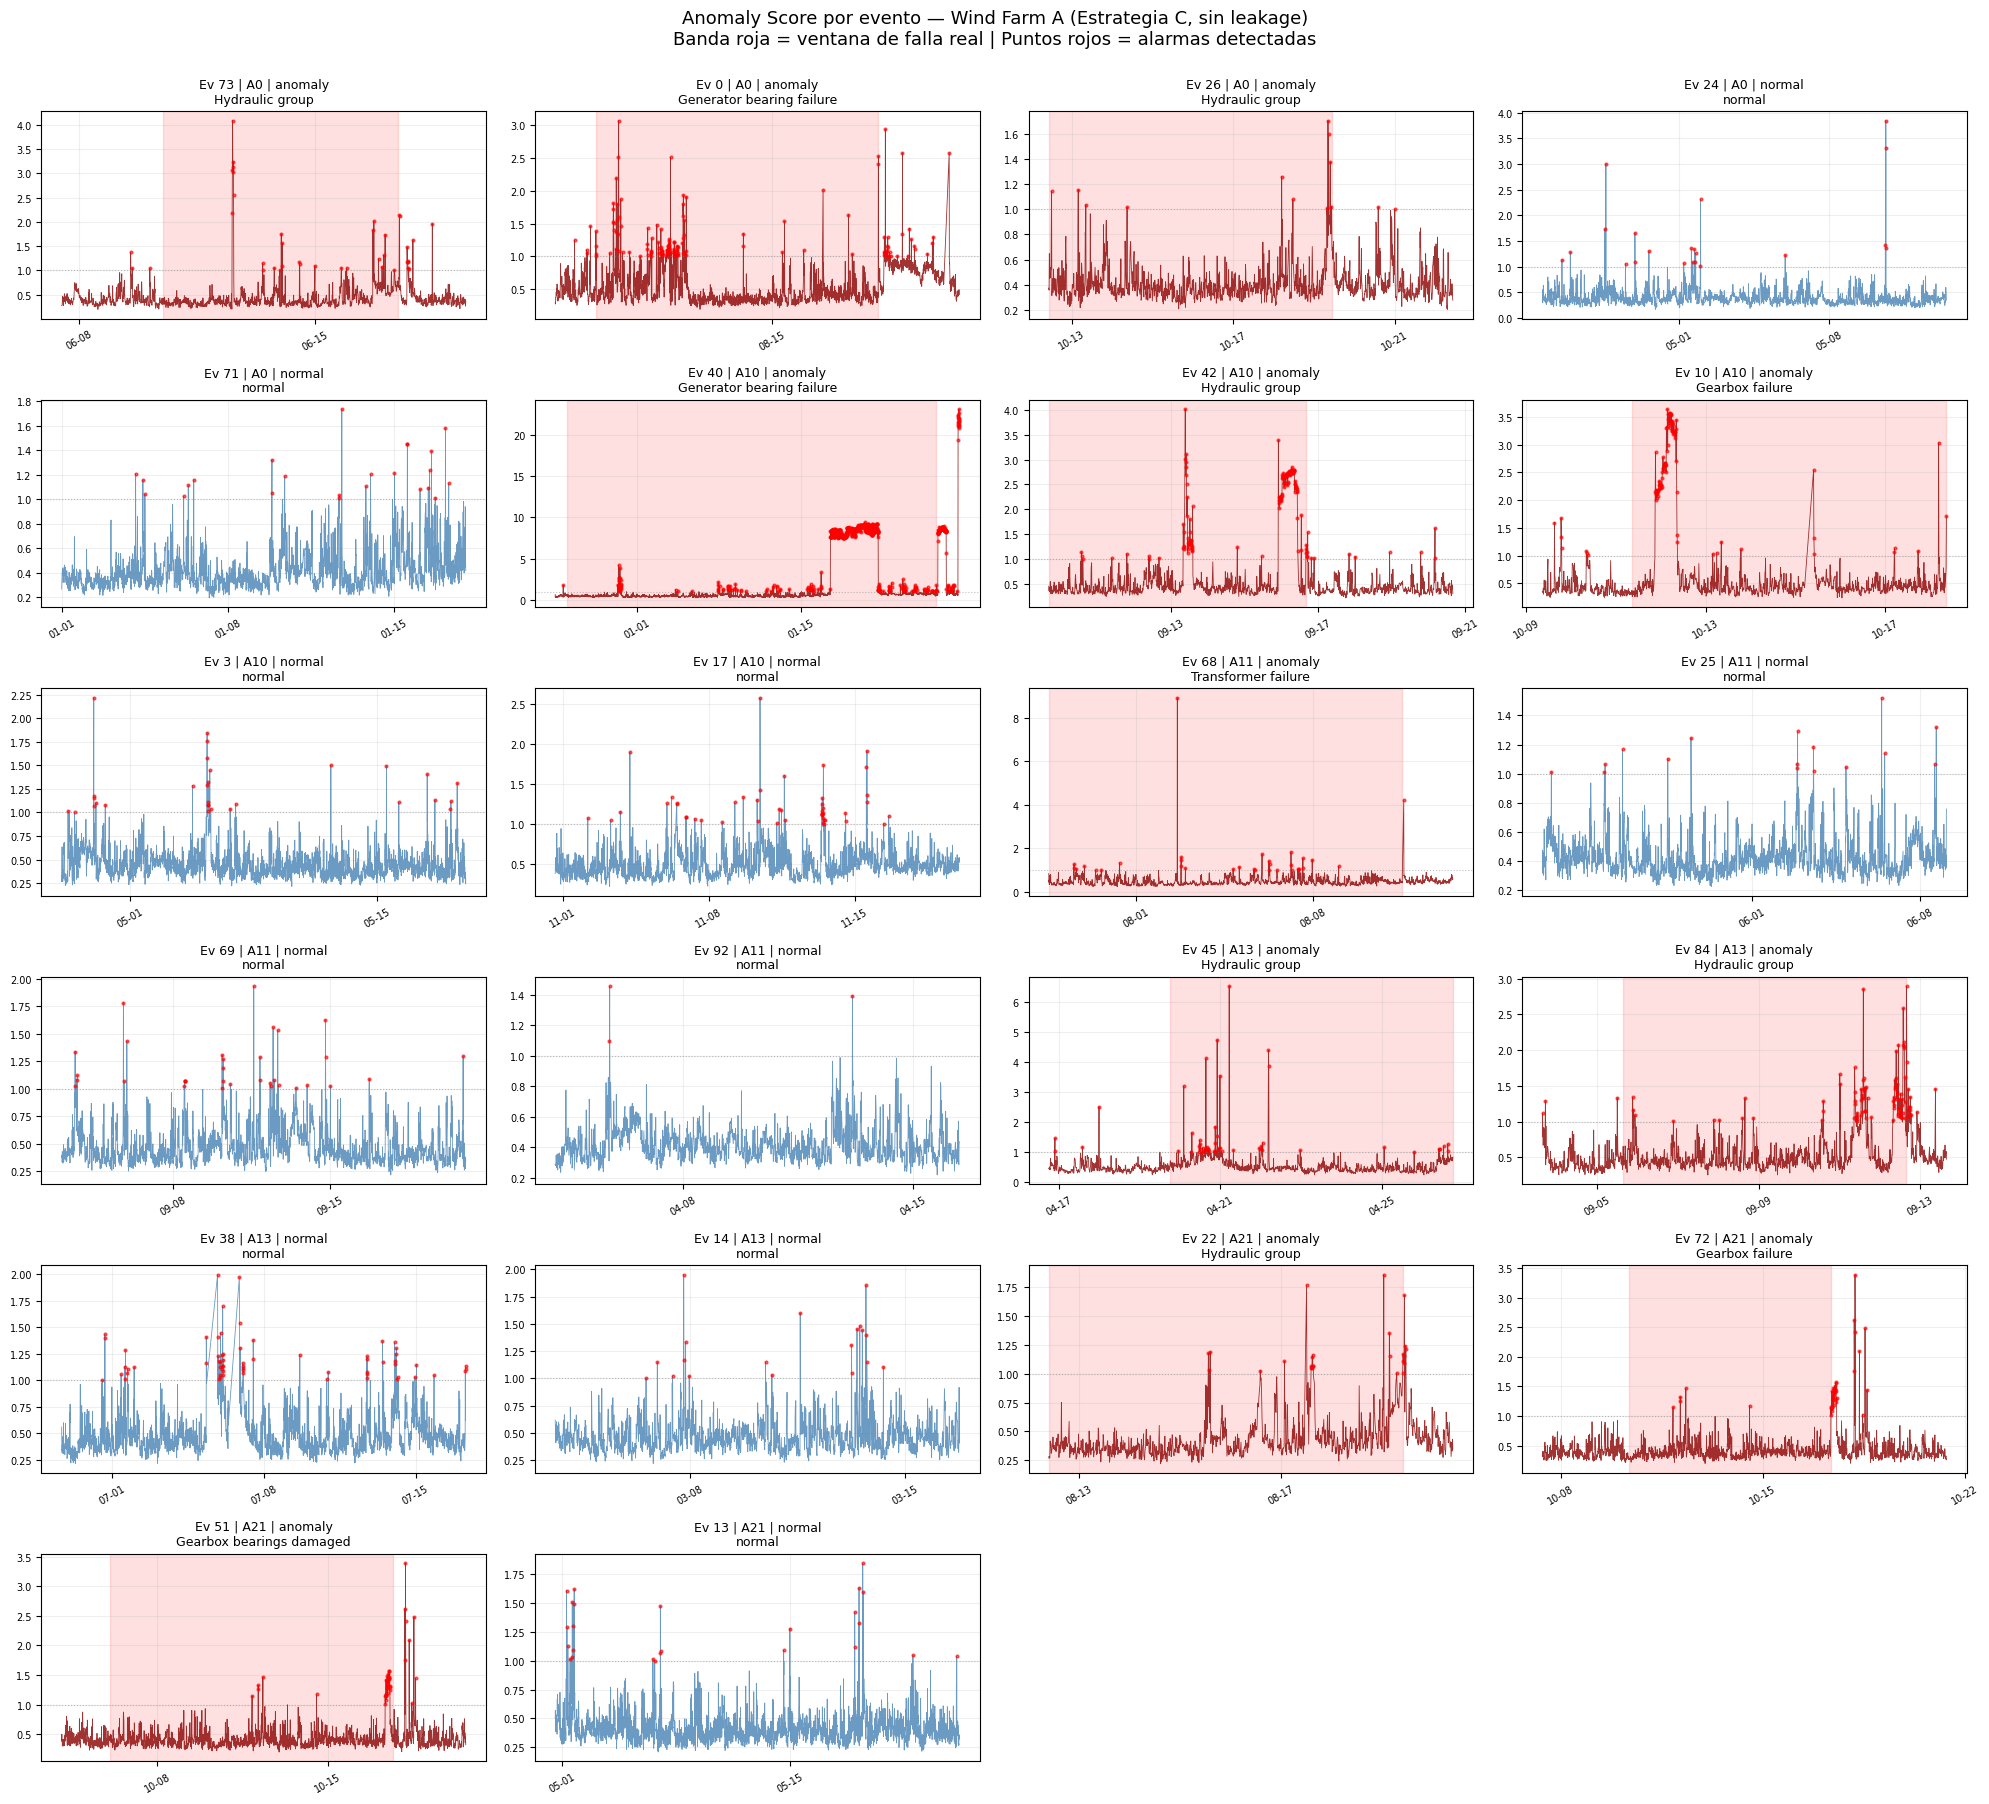

✅ Guardado: 01_panorama_22_eventos.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# Recolectar predicciones de todos los eventos usando los modelos limpios
all_predictions = {}
for asset_id, asset_events in event_info.groupby("asset"):
    artifacts = asset_artifacts_dict[asset_id]
    for evid in asset_events["event_id"]:
        anomaly_score, predicted_anomalies = predict_event(artifacts, evid)
        all_predictions[evid] = {
            "score": anomaly_score,
            "alarms": predicted_anomalies,
        }

# === VISUALIZACIÓN 1: Vista panorámica de los 22 eventos ===
fig, axes = plt.subplots(6, 4, figsize=(20, 18), sharey=False)
axes = axes.flatten()

# Ordenar por asset y dentro del asset por label (anomaly primero)
ordered = event_info.sort_values(by=["asset", "event_label"], ascending=[True, True])

for i, (_, ev) in enumerate(ordered.iterrows()):
    if i >= len(axes):
        break
    
    ax = axes[i]
    evid = ev["event_id"]
    score = all_predictions[evid]["score"]
    alarms = all_predictions[evid]["alarms"]
    
    fault_start = pd.to_datetime(ev["event_start"])
    fault_end = pd.to_datetime(ev["event_end"])
    
    # Score
    color_line = "darkred" if ev["event_label"] == "anomaly" else "steelblue"
    ax.plot(score.index, score.values, color=color_line, linewidth=0.6, alpha=0.8)
    
    # Umbral
    ax.axhline(1.0, color="gray", linestyle=":", alpha=0.5, linewidth=0.8)
    
    # Ventana de falla (solo para eventos anomaly)
    if ev["event_label"] == "anomaly":
        ax.axvspan(fault_start, fault_end, color="red", alpha=0.12)
    
    # Alarmas como puntos
    if alarms.sum() > 0:
        alarm_points = score[alarms]
        ax.scatter(alarm_points.index, alarm_points.values, 
                   color="red", s=4, alpha=0.6, zorder=5)
    
    # Título
    desc = ev["event_description"] if pd.notna(ev["event_description"]) else "normal"
    title = f"Ev {evid} | A{ev['asset']} | {ev['event_label']}\n{desc[:30]}"
    ax.set_title(title, fontsize=9)
    
    ax.tick_params(axis="x", labelsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(alpha=0.2)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

# Ocultar paneles vacíos
for j in range(len(ordered), len(axes)):
    axes[j].axis("off")

fig.suptitle("Anomaly Score por evento — Wind Farm A (Estrategia C, sin leakage)\n"
             "Banda roja = ventana de falla real | Puntos rojos = alarmas detectadas",
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig("01_panorama_22_eventos.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Guardado: 01_panorama_22_eventos.png")

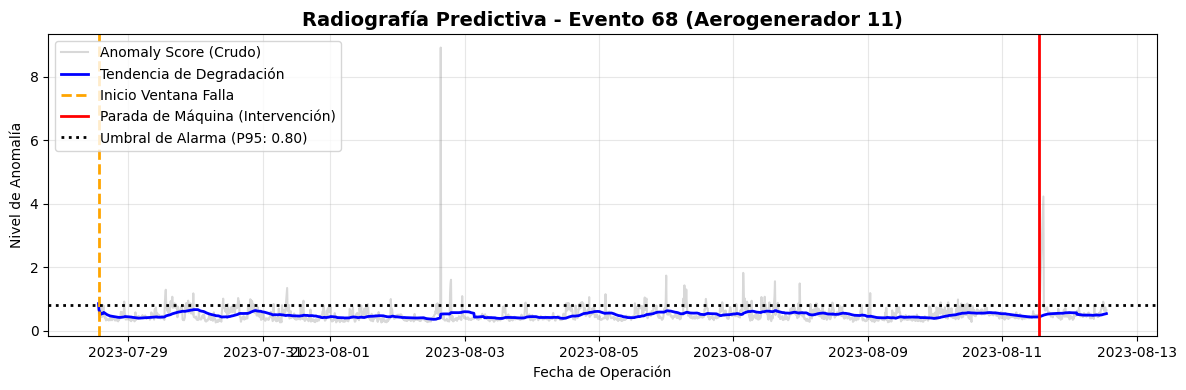

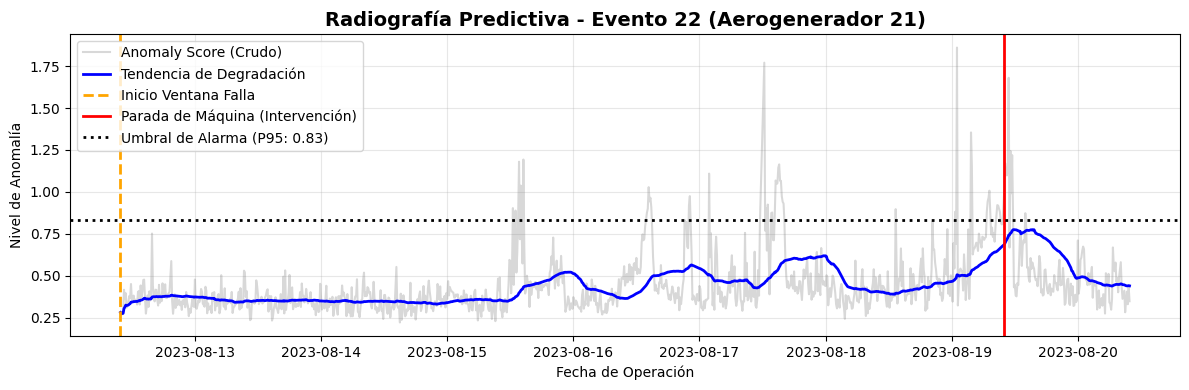

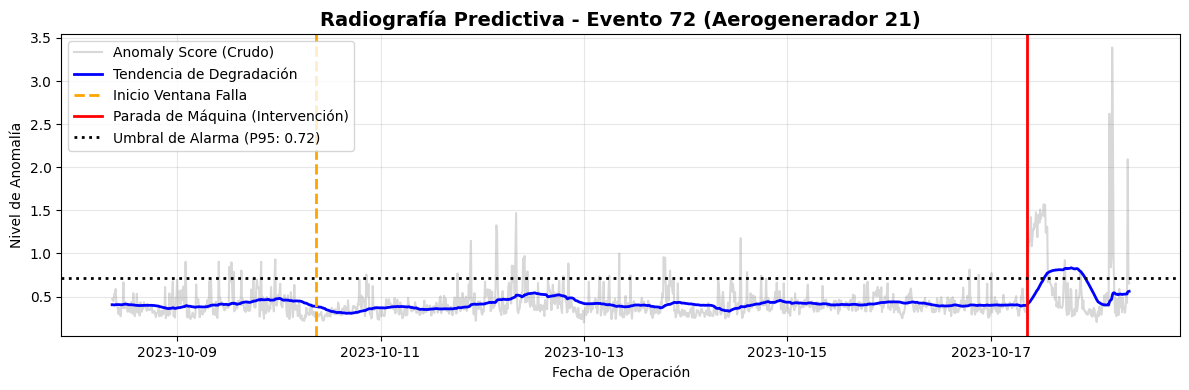

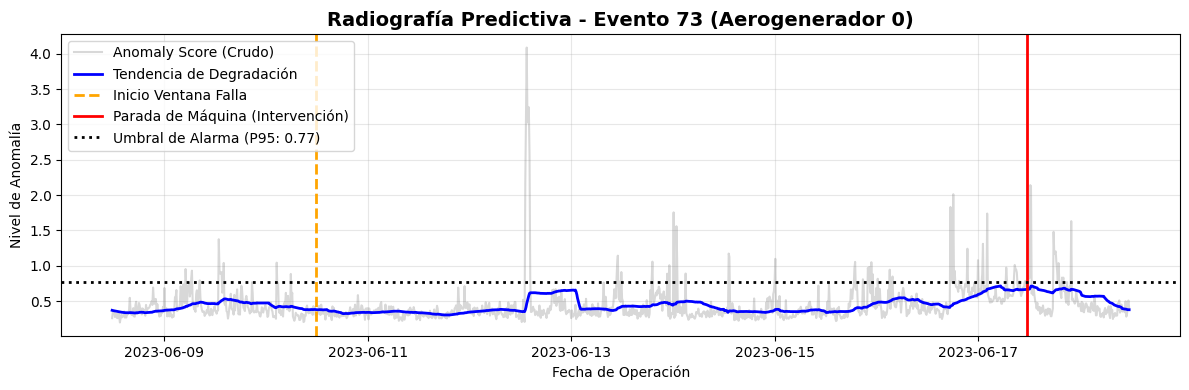

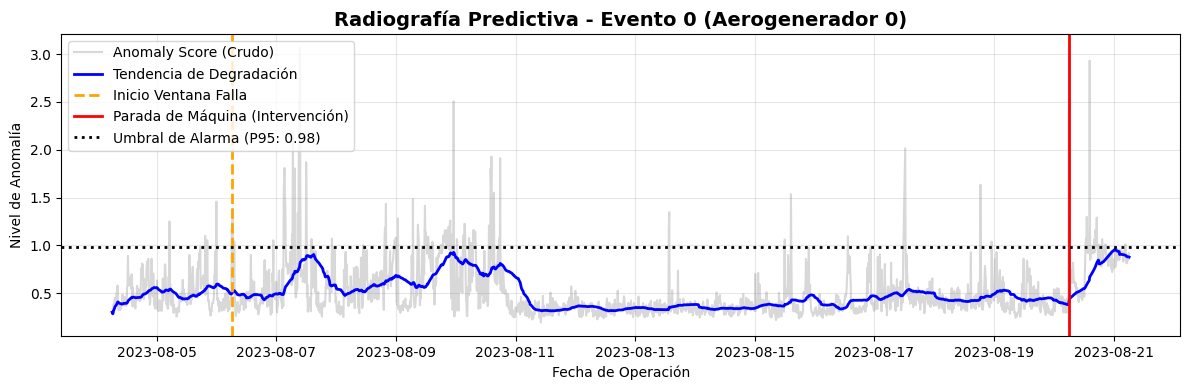

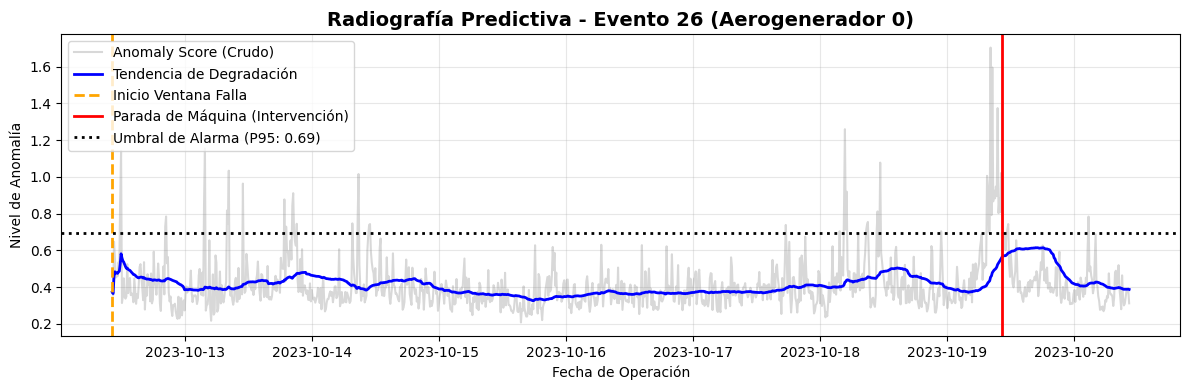

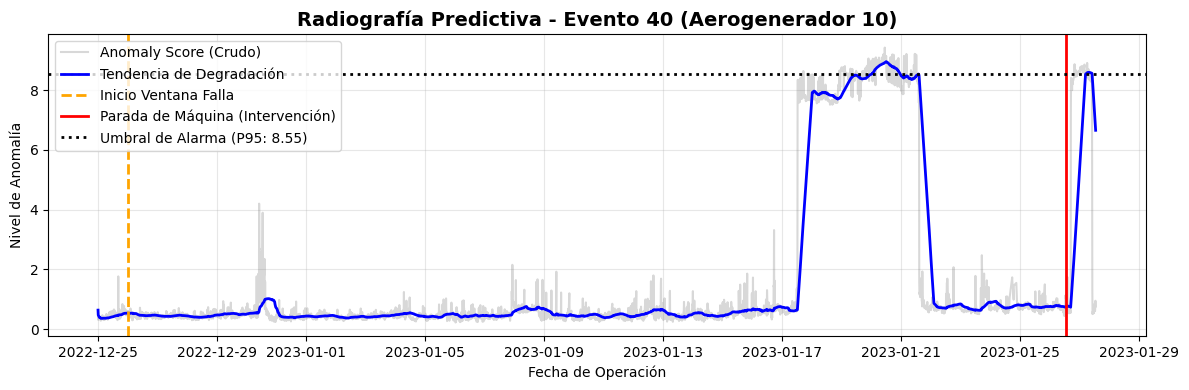

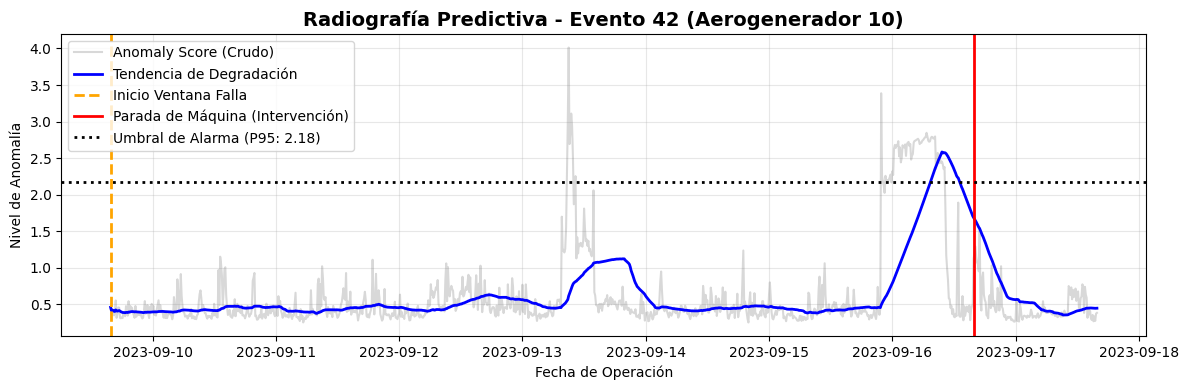

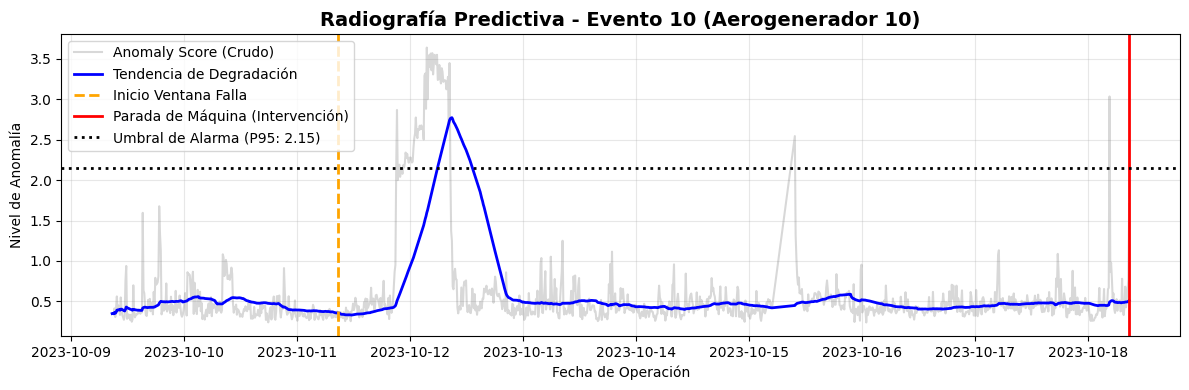

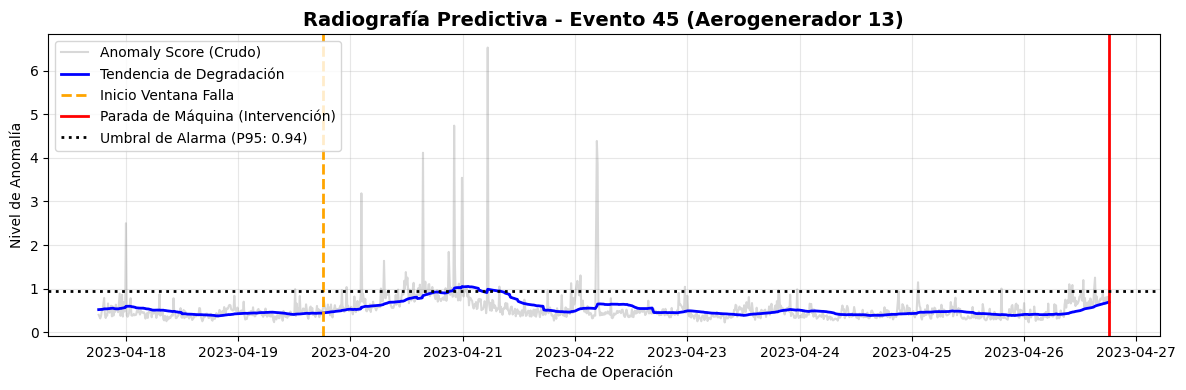

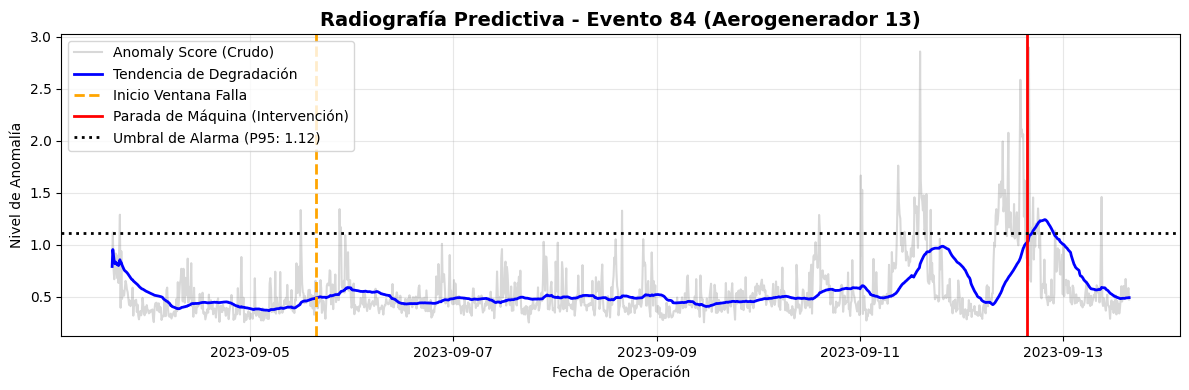

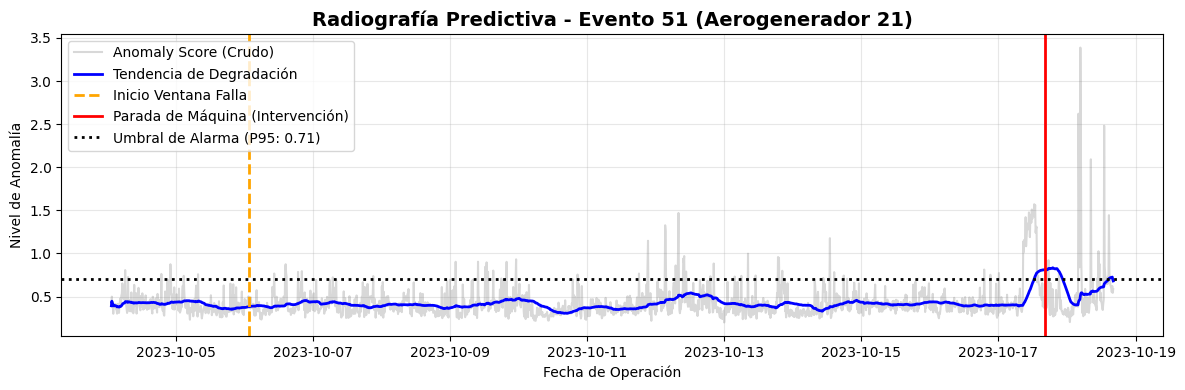

In [6]:
import matplotlib.pyplot as plt


# Iteramos sobre todos los eventos
anomaly = event_info[event_info["event_label"]=="anomaly"]
for ev_id in anomaly["event_id"].unique():
    
    # Extraemos información del evento
    ev_info_row = event_info.set_index("event_id").loc[ev_id]
    asset_del_evento = ev_info_row["asset"]
    fault_start = pd.to_datetime(ev_info_row["event_start"])
    fault_end = pd.to_datetime(ev_info_row["event_end"])
    
    # 1. Recuperar el modelo y predecir
    artifacts = asset_artifacts_dict[asset_del_evento]
    score_ev, _ = predict_event(artifacts, event_id=ev_id)
    
    # 2. Suavizar el score para ver la tendencia clara (Media móvil 12 horas)
    score_smooth = score_ev.rolling(window=72, min_periods=1).mean()
    
    # 3. Calcular el umbral P95
    umbral = score_ev.dropna().quantile(0.95)
    
    # 4. Crear la ventana visual (ver 2 días antes del inicio y 1 día después del final)
    ventana_visual = score_ev[(score_ev.index >= fault_start - pd.Timedelta(days=2)) & 
                              (score_ev.index <= fault_end + pd.Timedelta(days=1))]
    ventana_smooth = score_smooth.reindex(ventana_visual.index)
    
    # 5. Dibujar la Gráfica
    plt.figure(figsize=(12, 4))
    
    # Líneas de datos
    plt.plot(ventana_visual.index, ventana_visual.values, 
             alpha=0.3, color="gray", label="Anomaly Score (Crudo)")
    plt.plot(ventana_smooth.index, ventana_smooth.values, 
             linewidth=2, color="blue", label="Tendencia de Degradación")
    
    # Líneas de referencia (Fechas y Umbral)
    plt.axvline(fault_start, color="orange", linestyle="--", linewidth=2, label="Inicio Ventana Falla")
    plt.axvline(fault_end, color="red", linestyle="-", linewidth=2, label="Parada de Máquina (Intervención)")
    plt.axhline(umbral, color="black", linestyle=":", linewidth=2, label=f"Umbral de Alarma (P95: {umbral:.2f})")
    
    # Formato
    plt.title(f"Radiografía Predictiva - Evento {ev_id} (Aerogenerador {asset_del_evento})", fontsize=14, fontweight="bold")
    plt.xlabel("Fecha de Operación")
    plt.ylabel("Nivel de Anomalía")
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Mostrar la gráfica
    plt.show()

In [11]:
def first_alarm_diagnostic(asset_artifacts, event_id, fault_start, fault_end,
                            top_n=10, alarm_threshold=1.0):
    """
    1. Detecta el PRIMER momento donde el anomaly_score supera el umbral
       dentro de la ventana de falla
    2. Lista los top N sensores con mayor error de reconstrucción 
       EN ESE MOMENTO específico
    3. Devuelve la lista para que el ingeniero decida qué investigar
    """
    df = load_event(event_id)
    test_data = df[df["train_test"] == "prediction"]
    
    cols = asset_artifacts["cols"]
    X_test = test_data[cols].copy()
    X_imp = asset_artifacts["imputer"].transform(X_test)
    X_scaled = asset_artifacts["scaler"].transform(X_imp)
    X_recon = asset_artifacts["model"].predict(X_scaled, verbose=0)
    
    # Error de reconstrucción por sensor por timestamp
    recon_error = pd.DataFrame(
        np.abs(X_scaled - X_recon),
        index=test_data.index,
        columns=cols
    )
    
    # Anomaly score (RMSE) normalizado por el umbral del modelo
    rmse = np.sqrt(np.mean((X_scaled - X_recon)**2, axis=1))
    anomaly_score = pd.Series(
        rmse / asset_artifacts["threshold"],
        index=test_data.index
    )
    
    # PRIMERA ALARMA dentro de la ventana de falla
    in_window = (anomaly_score.index >= fault_start) & \
                (anomaly_score.index <= fault_end)
    alarms_in_window = anomaly_score[in_window & (anomaly_score > alarm_threshold)]
    
    if len(alarms_in_window) == 0:
        print(f"⚠️  No hay primera alarma dentro de la ventana de falla.")
        return None
    
    first_alarm_ts = alarms_in_window.index[0]
    
    # Sensores con mayor error EN EL MOMENTO de la primera alarma
    sensors_at_alarm = recon_error.loc[first_alarm_ts].sort_values(ascending=False).head(top_n)
    
    # También: top sensores promediados en las primeras 6 horas tras la alarma
    # (más estable que un solo timestamp)
    window_after = recon_error.loc[
        (recon_error.index >= first_alarm_ts) &
        (recon_error.index <= first_alarm_ts + pd.Timedelta(hours=6))
    ]
    sensors_first_6h = window_after.mean().sort_values(ascending=False).head(top_n)
    
    # Reporte
    print(f"\n{'='*70}")
    print(f"  PRIMERA ALARMA DETECTADA — Evento {event_id}")
    print(f"{'='*70}")
    print(f"  Timestamp: {first_alarm_ts.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  Anomaly score en alarma: {anomaly_score.loc[first_alarm_ts]:.3f}")
    print(f"")
    print(f"  TOP {top_n} sensores con MAYOR error en el instante de alarma:")
    print(f"  {'-'*60}")
    for i, (s, e) in enumerate(sensors_at_alarm.items(), 1):
        print(f"    {i:2d}. {s:35s} error={e:.4f}")
    print(f"")
    print(f"  TOP {top_n} sensores promediados en las primeras 6 horas:")
    print(f"  {'-'*60}")
    for i, (s, e) in enumerate(sensors_first_6h.items(), 1):
        print(f"    {i:2d}. {s:35s} error={e:.4f}")
    print(f"{'='*70}")
    
    return {
        "first_alarm_ts": first_alarm_ts,
        "anomaly_score": anomaly_score,
        "recon_error_full": recon_error,
        "sensors_at_alarm": sensors_at_alarm,
        "sensors_first_6h": sensors_first_6h,
    }

In [12]:
def plot_sensor_degradation(diagnostic_result, sensors_to_track,
                             fault_start, fault_end, event_id):
    """
    Grafica la evolución del error de reconstrucción de los sensores
    que TÚ decidiste investigar.
    
    Args:
        diagnostic_result: salida de first_alarm_diagnostic()
        sensors_to_track:  lista de nombres de sensores, ej: ["sensor_41_avg", "sensor_5_avg"]
    """
    recon_error = diagnostic_result["recon_error_full"]
    first_alarm = diagnostic_result["first_alarm_ts"]
    
    # Verificar que los sensores existen
    valid_sensors = [s for s in sensors_to_track if s in recon_error.columns]
    if len(valid_sensors) < len(sensors_to_track):
        missing = set(sensors_to_track) - set(valid_sensors)
        print(f"⚠️  Sensores no encontrados (ignorados): {missing}")
    
    if not valid_sensors:
        print("❌ Ningún sensor válido para graficar.")
        return None
    
    # Calcular tendencias diarias y pendientes
    fig, axes = plt.subplots(len(valid_sensors) + 1, 1,
                              figsize=(14, 3.5 * (len(valid_sensors) + 1)),
                              sharex=True)
    if len(valid_sensors) == 0:
        axes = [axes]
    elif len(valid_sensors) == 1:
        axes = list(axes) if hasattr(axes, '__len__') else [axes]
    
    slopes = {}
    
    # Un panel por sensor
    for i, sensor in enumerate(valid_sensors):
        ax = axes[i]
        
        # Error raw
        ax.plot(recon_error.index, recon_error[sensor].values,
                color="lightgray", linewidth=0.5, alpha=0.6,
                label="Error raw (10 min)")
        
        # Suavizado 24h
        smooth = recon_error[sensor].rolling(window=144, min_periods=1).mean()
        ax.plot(smooth.index, smooth.values,
                color="navy", linewidth=1.5, label="Suavizado 24h")
        
        # Tendencia diaria
        daily = recon_error[sensor].resample("D").mean().dropna()
        ax.plot(daily.index, daily.values,
                color="darkred", linewidth=2.5, marker="o", markersize=6,
                label="Media diaria")
        
        # Pendiente lineal (solo dentro de la ventana de falla)
        daily_in_window = daily[(daily.index >= fault_start) & 
                                 (daily.index <= fault_end)]
        if len(daily_in_window) >= 3:
            t_d = np.arange(len(daily_in_window))
            slope, intercept = np.polyfit(t_d, daily_in_window.values, 1)
            trend = slope * t_d + intercept
            ax.plot(daily_in_window.index, trend,
                    color="darkorange", linewidth=2, linestyle="--",
                    label=f"Tendencia: {slope:+.4f}/día")
            slopes[sensor] = slope
            
            # Clasificación visual
            if slope > 0.003:
                tipo = "GRADUAL CRECIENTE ✓"
                color_box = "lightgreen"
            elif slope > 0.001:
                tipo = "Levemente creciente"
                color_box = "lightyellow"
            elif slope < -0.001:
                tipo = "Decreciente"
                color_box = "lightblue"
            else:
                tipo = "PLANA (súbita)"
                color_box = "mistyrose"
            
            ax.text(0.02, 0.95, tipo,
                    transform=ax.transAxes, fontsize=10, fontweight="bold",
                    verticalalignment="top",
                    bbox=dict(boxstyle="round", facecolor=color_box, alpha=0.8))
        
        # Líneas de referencia
        ax.axvline(fault_start, color="orange", linestyle="--",
                   linewidth=1.2, label="Inicio ventana")
        ax.axvline(first_alarm, color="red", linestyle="-",
                   linewidth=1.5, label=f"Primera alarma")
        ax.axvline(fault_end, color="green", linestyle="--",
                   linewidth=1.2, label="Intervención")
        
        ax.set_ylabel("Error reconstrucción")
        ax.set_title(f"{sensor}")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(alpha=0.3)
    
    # Panel final: promedio de los sensores seleccionados
    ax_last = axes[-1]
    avg_error = recon_error[valid_sensors].mean(axis=1)
    avg_smooth = avg_error.rolling(window=144, min_periods=1).mean()
    avg_daily = avg_error.resample("D").mean().dropna()
    
    ax_last.plot(avg_error.index, avg_error.values,
                 color="lightgray", linewidth=0.5, alpha=0.6,
                 label="Promedio raw")
    ax_last.plot(avg_smooth.index, avg_smooth.values,
                 color="navy", linewidth=1.5, label="Suavizado 24h")
    ax_last.plot(avg_daily.index, avg_daily.values,
                 color="darkred", linewidth=2.5, marker="o", markersize=7,
                 label="Media diaria")
    
    avg_in_window = avg_daily[(avg_daily.index >= fault_start) & 
                              (avg_daily.index <= fault_end)]
    if len(avg_in_window) >= 3:
        t_d = np.arange(len(avg_in_window))
        slope_avg, intercept_avg = np.polyfit(t_d, avg_in_window.values, 1)
        trend_avg = slope_avg * t_d + intercept_avg
        ax_last.plot(avg_in_window.index, trend_avg,
                     color="darkorange", linewidth=2, linestyle="--",
                     label=f"Tendencia: {slope_avg:+.4f}/día")
        
        if slope_avg > 0.003:
            veredicto = "✓ DEGRADACIÓN GRADUAL — candidata para RUL"
        elif slope_avg > 0.001:
            veredicto = "⚠️  Tendencia débil — monitorear"
        else:
            veredicto = "❌ FALLA SÚBITA — RUL no aplicable, activar protocolo"
        
        print(f"\n{'='*70}")
        print(f"  VEREDICTO — Sensores seleccionados:")
        print(f"  {sensors_to_track}")
        print(f"{'='*70}")
        print(f"  Pendiente promedio: {slope_avg:+.4f}/día")
        print(f"  {veredicto}")
        print(f"{'='*70}")
    
    ax_last.axvline(fault_start, color="orange", linestyle="--", linewidth=1.2)
    ax_last.axvline(first_alarm, color="red", linestyle="-",
                    linewidth=1.5, label="Primera alarma")
    ax_last.axvline(fault_end, color="green", linestyle="--",
                    linewidth=1.2, label="Intervención")
    ax_last.set_ylabel("Error promedio")
    ax_last.set_xlabel("Fecha")
    ax_last.set_title(f"SEÑAL CONSOLIDADA — promedio de {len(valid_sensors)} sensores seleccionados")
    ax_last.legend(loc="upper left", fontsize=8)
    ax_last.grid(alpha=0.3)
    
    plt.suptitle(
        f"Seguimiento manual de sensores — Evento {event_id}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(f"sensores_manual_evento_{event_id}.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    
    return {
        "slopes": slopes,
        "avg_slope": slope_avg if len(avg_in_window) >= 3 else None,
        "veredicto": veredicto if len(avg_in_window) >= 3 else "Insuficientes datos",
    }


  PRIMERA ALARMA DETECTADA — Evento 51
  Timestamp: 2023-10-11 21:20:00
  Anomaly score en alarma: 1.147

  TOP 10 sensores con MAYOR error en el instante de alarma:
  ------------------------------------------------------------
     1. sensor_52_min                       error=0.6337
     2. sensor_18_min                       error=0.4688
     3. sensor_31_std                       error=0.4133
     4. sensor_41_avg                       error=0.3450
     5. sensor_44                           error=0.3094
     6. sensor_31_min                       error=0.3080
     7. sensor_5_max                        error=0.2812
     8. sensor_0_avg                        error=0.2682
     9. sensor_6_avg                        error=0.2656
    10. sensor_36_avg                       error=0.2331

  TOP 10 sensores promediados en las primeras 6 horas:
  ------------------------------------------------------------
     1. sensor_31_std                       error=0.1150
     2. sensor_40_avg   

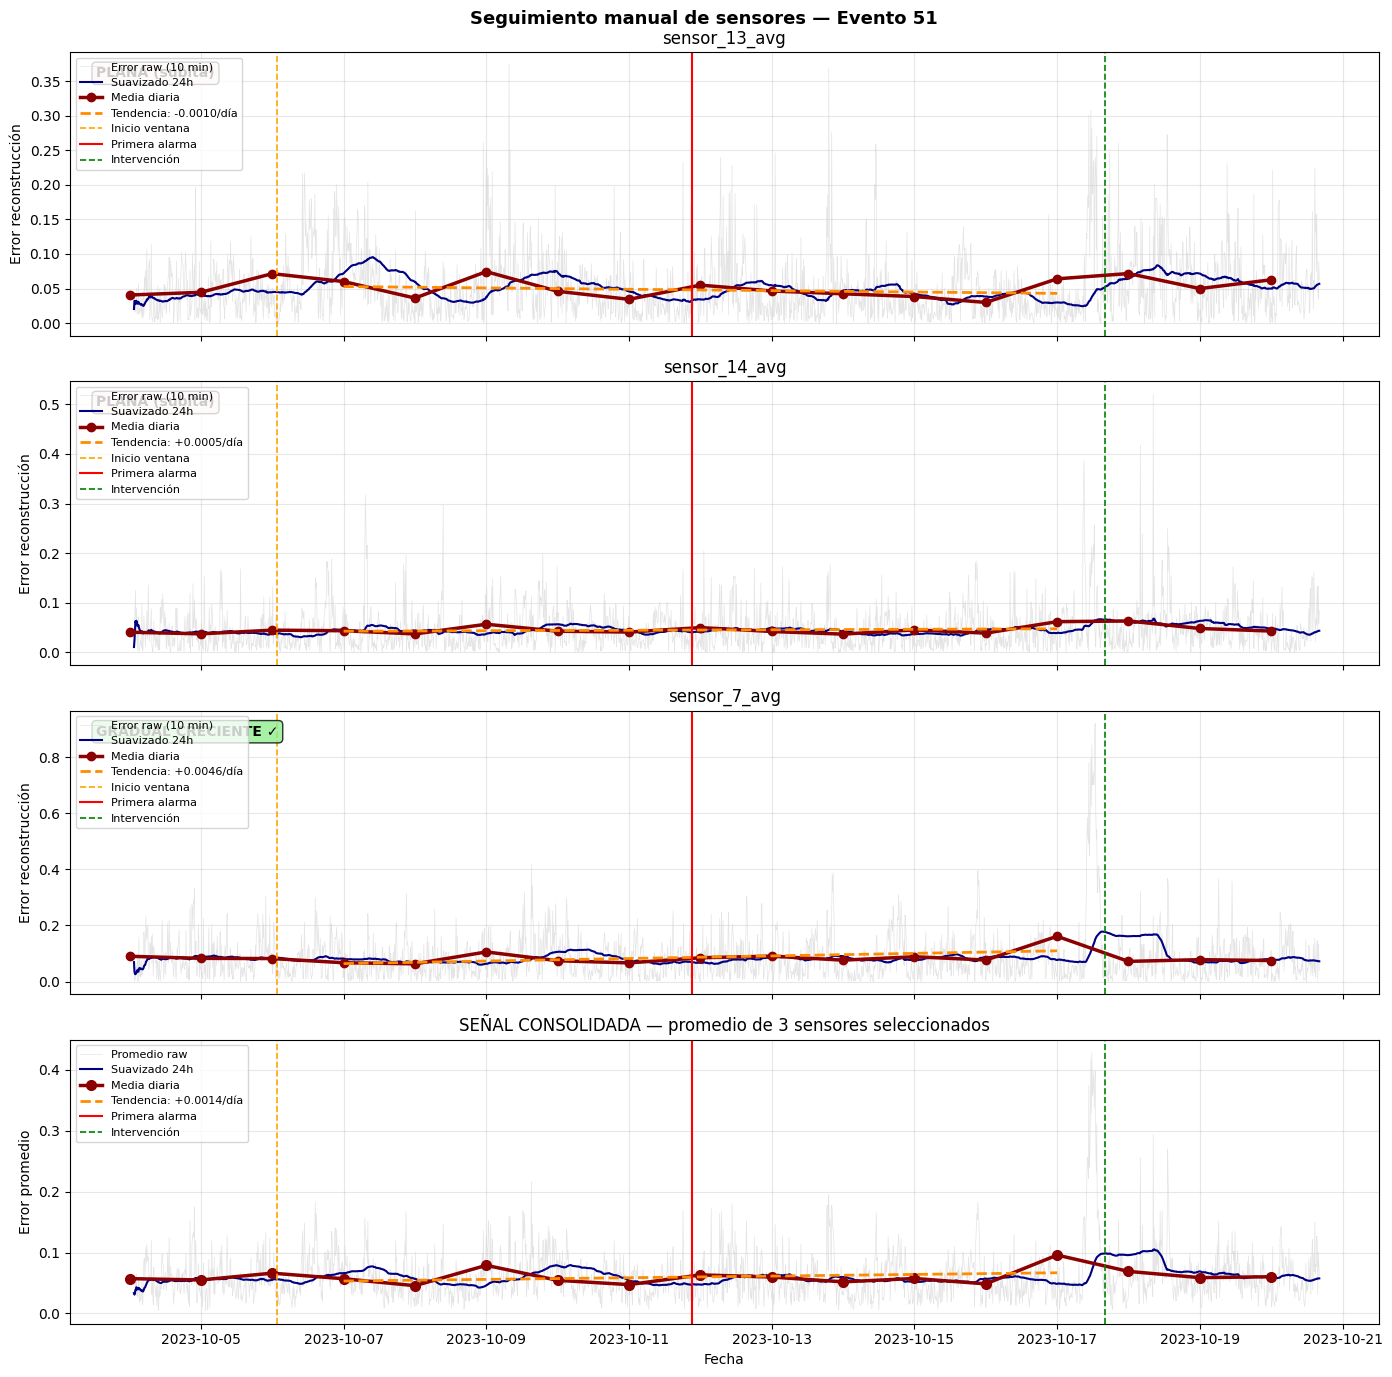

In [13]:
# === PASO 1: detectar primera alarma y ver qué sensores se dispararon ===
ev22 = event_info.set_index("event_id").loc[51]
diag = first_alarm_diagnostic(
    asset_artifacts=asset_artifacts_dict[21],
    event_id=51,
    fault_start=pd.to_datetime(ev22["event_start"]),
    fault_end=pd.to_datetime(ev22["event_end"]),
    top_n=10,
)

# [Aquí ves la lista de 10 sensores y decides cuáles te interesan]

# === PASO 2: TÚ eliges qué sensores investigar ===
# Por ejemplo, si crees que es hidráulico:
mis_sensores = ["sensor_13_avg", "sensor_14_avg", "sensor_7_avg"]

# O si crees que es térmico:
# mis_sensores = ["sensor_14_avg", "sensor_18_avg"]

# === PASO 3: graficar la evolución de TUS sensores elegidos ===
resultado = plot_sensor_degradation(
    diagnostic_result=diag,
    sensors_to_track=mis_sensores,
    fault_start=pd.to_datetime(ev22["event_start"]),
    fault_end=pd.to_datetime(ev22["event_end"]),
    event_id=51
)